In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn import metrics
import re
from numpy import random
import seaborn as sb

protein0 = pd.read_csv('77_cancer_proteomes_CPTAC_itraq.csv')
clinical_sample = pd.read_csv('clinical_data_breast_cancer.csv')
pam50 = pd.read_csv('PAM50_proteins.csv')
protein = protein0.copy()
new_cols = list(protein0.columns[:3])
new_cols += [col[:7] for col in protein.columns[3:]]
protein.columns = new_cols
protein = protein.loc[:,~protein.columns.duplicated(keep='first')]
print("\n=== 蛋白质数据 info ===")
print(protein.info())
print("\n=== 每列缺失值数量 ===")
print(protein.isnull().sum())
print("\n=== 每行缺失值数量 ===")
print(protein.isnull().sum(axis=1))
print("\n=== 基因分类 value_counts ===")
print(protein['gene_name'].value_counts())


=== 蛋白质数据 info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12553 entries, 0 to 12552
Data columns (total 83 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   RefSeq_accession_number  12553 non-null  object 
 1   gene_symbol              10773 non-null  object 
 2   gene_name                12553 non-null  object 
 3   AO-A12D                  11334 non-null  float64
 4   C8-A131                  11335 non-null  float64
 5   AO-A12B                  11334 non-null  float64
 6   BH-A18Q                  12024 non-null  float64
 7   C8-A130                  12025 non-null  float64
 8   C8-A138                  11833 non-null  float64
 9   E2-A154                  11833 non-null  float64
 10  C8-A12L                  11732 non-null  float64
 11  A2-A0EX                  11732 non-null  float64
 12  AN-A04A                  11276 non-null  float64
 13  BH-A0AV                  11274 non-null  float64
 14  C8

In [3]:
clinical = clinical_sample.copy()
clinical['Complete TCGA ID'] = clinical['Complete TCGA ID'].str[-7:]
clinical = clinical[clinical['Complete TCGA ID'].isin(new_cols)]
print("\n=== 临床数据 info ===")
print(clinical.info())
print(clinical.columns.tolist())


=== 临床数据 info ===
<class 'pandas.core.frame.DataFrame'>
Index: 77 entries, 1 to 104
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Complete TCGA ID                     77 non-null     object 
 1   Gender                               77 non-null     object 
 2   Age at Initial Pathologic Diagnosis  77 non-null     int64  
 3   ER Status                            77 non-null     object 
 4   PR Status                            77 non-null     object 
 5   HER2 Final Status                    77 non-null     object 
 6   Tumor                                77 non-null     object 
 7   Tumor--T1 Coded                      77 non-null     object 
 8   Node                                 77 non-null     object 
 9   Node-Coded                           77 non-null     object 
 10  Metastasis                           77 non-null     object 
 11  Metastasis-Coded   

In [4]:
def fillna_with_row_min(df):
    row_min = df.min(axis=1, skipna=True)
    target_min = target_value = row_min - row_min.abs() * 0.4
    return df.where(df.notna(), target_min, axis=0)
column_first = protein.columns[:3]
column_last = protein.columns[3:]
mask = protein[column_last].isna().mean(axis=1) <= 0.36
protein_filtered = protein[mask].copy()
protein_filtered[column_last] = fillna_with_row_min(protein_filtered[column_last])
protein = protein_filtered
print("\n=== 缺失值填补 ===")
print(protein.info())
print(protein.isnull().sum())
print(clinical.columns.tolist())


=== 缺失值填补 ===
<class 'pandas.core.frame.DataFrame'>
Index: 10868 entries, 0 to 12543
Data columns (total 83 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   RefSeq_accession_number  10868 non-null  object 
 1   gene_symbol              9352 non-null   object 
 2   gene_name                10868 non-null  object 
 3   AO-A12D                  10868 non-null  float64
 4   C8-A131                  10868 non-null  float64
 5   AO-A12B                  10868 non-null  float64
 6   BH-A18Q                  10868 non-null  float64
 7   C8-A130                  10868 non-null  float64
 8   C8-A138                  10868 non-null  float64
 9   E2-A154                  10868 non-null  float64
 10  C8-A12L                  10868 non-null  float64
 11  A2-A0EX                  10868 non-null  float64
 12  AN-A04A                  10868 non-null  float64
 13  BH-A0AV                  10868 non-null  float64
 14  C8-A12T     

In [5]:
protein_T = protein.set_index('RefSeq_accession_number').T
print(protein_T.info())

<class 'pandas.core.frame.DataFrame'>
Index: 82 entries, gene_symbol to c4155b-
Columns: 10868 entries, NP_958782 to NP_001193600
dtypes: object(10868)
memory usage: 6.8+ MB
None


In [6]:
import pandas as pd

# ================= 1. 处理蛋白质数据 =================

protein_T_clean = protein_T.iloc[2:].copy()

# 将索引重命名为 'SampleID' 并变成普通列
protein_T_clean = protein_T_clean.rename_axis('SampleID').reset_index()

# 【核心修复】：由于前三行的存在，所有列现在都是 object。
# 我们需要把除了 SampleID 之外的列全部强制转换为数值型（float）
cols_to_convert = protein_T_clean.columns.drop('SampleID') # 获取除去 ID 外的所有蛋白质列名
# 将这些列转为数值型，如果遇到无法转换的异常值，自动变成 NaN (缺失值)
protein_T_clean[cols_to_convert] = protein_T_clean[cols_to_convert].apply(pd.to_numeric, errors='coerce')

# ================= 2. 处理临床数据 =================
clinical_clean = clinical.rename(columns={'Complete TCGA ID': 'SampleID'})
merged = pd.merge(protein_T_clean, clinical_clean, on='SampleID', how='inner')
merged_numerical = merged.set_index('SampleID').select_dtypes(include='number')

print(merged_numerical.info())
print("合并后数据的维度:", merged_numerical.shape)
print("前几行数据:\n", merged_numerical.head())

<class 'pandas.core.frame.DataFrame'>
Index: 77 entries, AO-A12D to A2-A0SX
Columns: 10881 entries, NP_958782 to Integrated Clusters (unsup exp)
dtypes: float64(10869), int64(12)
memory usage: 6.4+ MB
None
合并后数据的维度: (77, 10881)
前几行数据:
           NP_958782  NP_958785  NP_958786  NP_000436  NP_958781  NP_958780  \
SampleID                                                                     
AO-A12D    1.096131   1.111370   1.111370   1.107561   1.115180   1.107561   
C8-A131    2.609943   2.650422   2.650422   2.646374   2.646374   2.646374   
AO-A12B   -0.659828  -0.648742  -0.654285  -0.632113  -0.640428  -0.654285   
BH-A18Q    0.195341   0.215413   0.215413   0.205377   0.215413   0.215413   
C8-A130   -0.494060  -0.503899  -0.500619  -0.510459  -0.503899  -0.503899   

          NP_958783  NP_958784  NP_112598  NP_001611  ...  OS event  OS Time  \
SampleID                                              ...                      
AO-A12D    1.111370   1.111370  -1.517390   0.482754  ...

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, homogeneity_score
valid_proteins = set(protein['RefSeq_accession_number'].astype(str))
protein_column = [col for col in merged_numerical.columns if str(col) in valid_proteins]
merged_numerical = merged_numerical[protein_column]
merged_numerical.columns = merged_numerical.columns.astype(str)
print("合并后数据的形状 (行数, 列数):", merged_numerical.shape)
scaler = StandardScaler()
merged_numerical_cluster = scaler.fit_transform(merged_numerical)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(merged_numerical_cluster)
print(f"PCA 降维后，特征数量从 {merged_numerical.shape[1]} 降到了 {X_pca.shape[1]}")
def compare_k_means(k_list, data, true_labels):
    """
    运行不同 k 值的 KMeans 聚类，并输出评估指标
    """
    print("\n开始评估不同 K 值的聚类效果：")
    for k in k_list:
        # n_init='auto' 可以避免新版 sklearn 的警告，random_state 保证可重复性
        clusterer = KMeans(n_clusters=k, random_state=42, n_init='auto')
        
        # 训练并直接获取聚类标签
        cluster_labels = clusterer.fit_predict(data)
        
        # 1. 计算轮廓系数 (Silhouette Coefficient)：评估聚类本身的紧凑度和分离度
        # 范围 [-1, 1]，越接近 1 越好
        sil_score = silhouette_score(data, cluster_labels)
        print(f"Silhouette Coefficient for k == {k}: {round(sil_score, 4)}")
        
        # 2. 计算同质性得分 (Homogeneity score)：评估聚类结果与临床真实标签的一致性
        # 范围 [0, 1]，越接近 1 越好
        homo_score = homogeneity_score(true_labels, cluster_labels)
        print(f"Homogeneity score for k == {k}: {round(homo_score, 4)}")
        print("-" * 35)
n_clusters = [2, 3, 4, 5, 6, 7, 8]
compare_k_means(n_clusters, X_pca, merged.set_index('SampleID')['PAM50 mRNA'].fillna('Unknown'))

合并后数据的形状 (行数, 列数): (77, 10868)
PCA 降维后，特征数量从 10868 降到了 64

开始评估不同 K 值的聚类效果：
Silhouette Coefficient for k == 2: 0.0624
Homogeneity score for k == 2: 0.0214
-----------------------------------
Silhouette Coefficient for k == 3: 0.0462
Homogeneity score for k == 3: 0.0673
-----------------------------------
Silhouette Coefficient for k == 4: 0.035
Homogeneity score for k == 4: 0.1441
-----------------------------------
Silhouette Coefficient for k == 5: 0.0265
Homogeneity score for k == 5: 0.2094
-----------------------------------
Silhouette Coefficient for k == 6: 0.0217
Homogeneity score for k == 6: 0.2143
-----------------------------------
Silhouette Coefficient for k == 7: 0.0232
Homogeneity score for k == 7: 0.2663
-----------------------------------
Silhouette Coefficient for k == 8: 0.0335
Homogeneity score for k == 8: 0.2956
-----------------------------------


In [8]:
from sklearn.decomposition import KernelPCA
kpca =KernelPCA(n_components=50,kernel='rbf',gamma=0.1,random_state = 42)
X_kpca = kpca.fit_transform(merged_numerical_cluster)
compare_k_means(n_clusters, X_kpca, merged.set_index('SampleID')['PAM50 mRNA'].fillna('Unknown'))


开始评估不同 K 值的聚类效果：
Silhouette Coefficient for k == 2: 0.0597
Homogeneity score for k == 2: 0.0165
-----------------------------------
Silhouette Coefficient for k == 3: -0.0145
Homogeneity score for k == 3: 0.0394
-----------------------------------
Silhouette Coefficient for k == 4: -0.022
Homogeneity score for k == 4: 0.0599
-----------------------------------
Silhouette Coefficient for k == 5: -0.026
Homogeneity score for k == 5: 0.0499
-----------------------------------
Silhouette Coefficient for k == 6: -0.0269
Homogeneity score for k == 6: 0.0597
-----------------------------------
Silhouette Coefficient for k == 7: -0.0248
Homogeneity score for k == 7: 0.0707
-----------------------------------
Silhouette Coefficient for k == 8: -0.016
Homogeneity score for k == 8: 0.1394
-----------------------------------


In [9]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score, homogeneity_score
import numpy as np
def compare_spectral_clustering(n_clusters_list, data, true_labels):
    print("开始评估不同 K 值的谱聚类效果：")
    for k in n_clusters_list:
        # 谱聚类模型，常用affinity='rbf'（高斯核），也可用'nearest_neighbors'
        spectral = SpectralClustering(
            n_clusters=k,
            affinity='rbf',          # 高斯核，可调参数gamma
            gamma=0.1,               # 核宽度，可根据数据调整
            assign_labels='kmeans',  # 最后一步用kmeans分配标签
            random_state=42
        )
        cluster_labels = spectral.fit_predict(data)
        
        # 轮廓系数（评估聚类紧密度和分离度）
        # 注意：当k=1时轮廓系数未定义，但这里k>=2
        if len(set(cluster_labels)) > 1:
            sil = silhouette_score(data, cluster_labels)
        else:
            sil = np.nan
        
        # 同质性得分（与真实标签的一致性）
        homo = homogeneity_score(true_labels, cluster_labels)
        print(f"Silhouette Coefficient for k == {k}: {sil:.4f}")
        print(f"Homogeneity score for k == {k}: {homo:.4f}")
        print("--" * 35)
compare_spectral_clustering(n_clusters, X_pca, merged.set_index('SampleID')['PAM50 mRNA'].fillna('Unknown'))

开始评估不同 K 值的谱聚类效果：
Silhouette Coefficient for k == 2: -0.0515
Homogeneity score for k == 2: 0.0125
----------------------------------------------------------------------
Silhouette Coefficient for k == 3: -0.0859
Homogeneity score for k == 3: 0.0366
----------------------------------------------------------------------
Silhouette Coefficient for k == 4: -0.0859
Homogeneity score for k == 4: 0.0366
----------------------------------------------------------------------
Silhouette Coefficient for k == 5: -0.1161
Homogeneity score for k == 5: 0.0499
----------------------------------------------------------------------
Silhouette Coefficient for k == 6: -0.0859
Homogeneity score for k == 6: 0.0366
----------------------------------------------------------------------
Silhouette Coefficient for k == 7: -0.0859
Homogeneity score for k == 7: 0.0366
----------------------------------------------------------------------
Silhouette Coefficient for k == 8: -0.0859
Homogeneity score for k == 8: 0.0

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn import metrics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
best_kmeans = KMeans(n_clusters=7,random_state = 42,n_init='auto')
cluster_labels = best_kmeans.fit_predict(X_pca)
true_labels = merged.set_index('SampleID')['PAM50 mRNA'].fillna('Unknown').values
def print_clustering_metrics(data, cluster_labels, true_labels):
    sil_score = metrics.silhouette_score(data, cluster_labels)
    calinski = metrics.calinski_harabasz_score(data, cluster_labels)
    print(f"轮廓系数 (Silhouette Score) [-1 到 1，越大越好]: {sil_score:.4f}")
    print(f"CH 指数 (Calinski-Harabasz) [越大越好]: {calinski:.2f}")
print_clustering_metrics(X_pca, cluster_labels, true_labels)

轮廓系数 (Silhouette Score) [-1 到 1，越大越好]: 0.0232
CH 指数 (Calinski-Harabasz) [越大越好]: 2.91


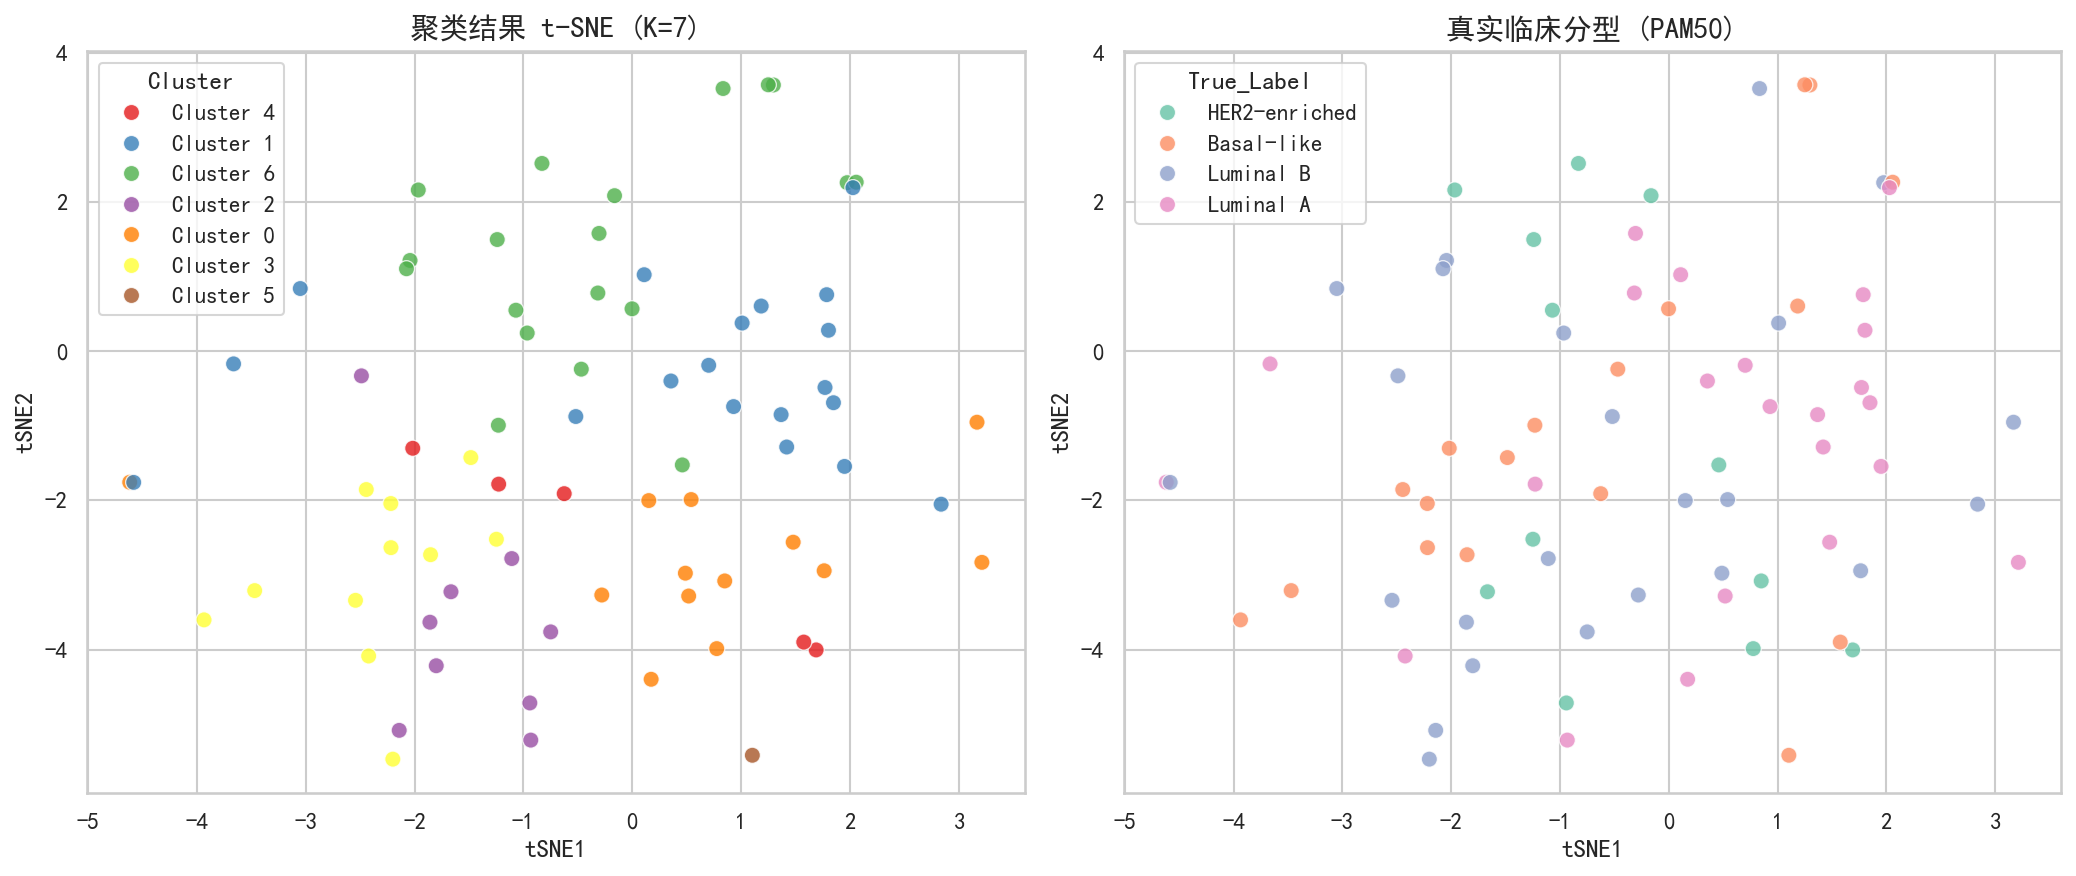

In [11]:
# 1. 运行 t-SNE 降维 (适合用于可视化聚类分布)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca) # 基于 PCA 的结果再做 t-SNE 效果更好

# 2. 构建画图用的 DataFrame
plot_df = pd.DataFrame({
    'PCA1': X_pca[:, 0], 'PCA2': X_pca[:, 1],
    'tSNE1': X_tsne[:, 0], 'tSNE2': X_tsne[:, 1],
    'Cluster': [f"Cluster {i}" for i in cluster_labels],
    'True_Label': true_labels
})

# 3. 开始画图：左边看预测的聚类，右边看真实的临床分型
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# 预测结果
sns.scatterplot(data=plot_df, x='tSNE1', y='tSNE2', hue='Cluster', 
                palette='Set1', s=60, alpha=0.8, ax=axes[0])
axes[0].set_title(f"聚类结果 t-SNE (K={7})", fontsize=14)

# 真实标签
sns.scatterplot(data=plot_df, x='tSNE1', y='tSNE2', hue='True_Label', 
                palette='Set2', s=60, alpha=0.8, ax=axes[1])
axes[1].set_title("真实临床分型 (PAM50)", fontsize=14)

plt.tight_layout()
plt.show()

In [12]:
valid_pam_ids = set(pam50['RefSeqProteinID'].dropna().astype(str).str.strip())
pam_protein = [col for col in merged_numerical.columns if str(col).strip() in valid_pam_ids]
merged_pam = merged_numerical[pam_protein]
print(len(merged_pam.columns))

38


In [13]:
df_features = merged_pam.copy()
df_features = df_features.reset_index()
df_labels = clinical_clean[['SampleID','PAM50 mRNA']]
df_combined = pd.merge(df_features, df_labels, on='SampleID', how='inner')
X_df = df_combined.drop(columns=['SampleID', 'PAM50 mRNA'])
y_series = df_combined['PAM50 mRNA']
print(X_df.info())
print(y_series.info())
print(f"对齐后的可用样本数量: {len(df_combined)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 38 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   NP_057427     77 non-null     float64
 1   NP_002408     77 non-null     float64
 2   NP_000415     77 non-null     float64
 3   NP_000413     77 non-null     float64
 4   NP_000517     77 non-null     float64
 5   NP_004439     77 non-null     float64
 6   NP_005219     77 non-null     float64
 7   NP_058519     77 non-null     float64
 8   NP_058518     77 non-null     float64
 9   NP_001116539  77 non-null     float64
 10  NP_061155     77 non-null     float64
 11  NP_001035932  77 non-null     float64
 12  NP_077006     77 non-null     float64
 13  NP_000917     77 non-null     float64
 14  NP_065178     77 non-null     float64
 15  NP_006836     77 non-null     float64
 16  NP_006614     77 non-null     float64
 17  NP_001784     77 non-null     float64
 18  NP_006092     77 non-null     fl

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_series)
target_names = label_encoder.classes_
n_classes = len(target_names)
print(f"检测到的 PAM50 亚型: {target_names}")
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"训练集样本数: {X_train.shape[0]}, 测试集样本数: {X_test.shape[0]}\n")

检测到的 PAM50 亚型: ['Basal-like' 'HER2-enriched' 'Luminal A' 'Luminal B']
训练集样本数: 61, 测试集样本数: 16




==================== 正在执行: 随机森林 交叉验证网格搜索 ====================
交叉验证找到的 随机森林 最佳参数: {'max_depth': None, 'n_estimators': 100}
交叉验证最高平均准确率: 0.6885

==================== 正在评估: 最优随机森林 ====================
               precision    recall  f1-score   support

   Basal-like       0.67      1.00      0.80         4
HER2-enriched       0.00      0.00      0.00         2
    Luminal A       1.00      0.20      0.33         5
    Luminal B       0.56      1.00      0.71         5

     accuracy                           0.62        16
    macro avg       0.56      0.55      0.46        16
 weighted avg       0.65      0.62      0.53        16



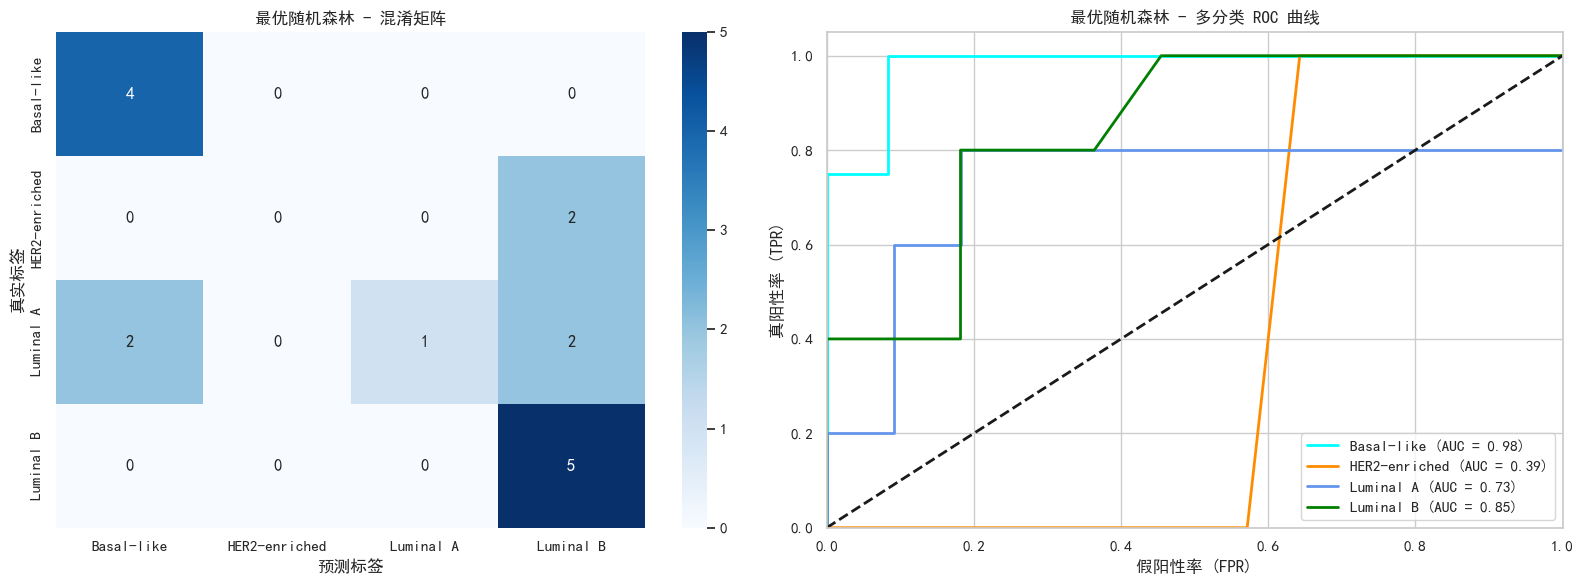


==================== 正在执行: 非线性SVM 交叉验证网格搜索 ====================
交叉验证找到的 SVM 最佳参数: {'C': 1, 'gamma': 'scale'}
交叉验证最高平均准确率: 0.7526

==================== 正在评估: 最优非线性 SVM ====================
               precision    recall  f1-score   support

   Basal-like       0.80      1.00      0.89         4
HER2-enriched       0.00      0.00      0.00         2
    Luminal A       1.00      0.60      0.75         5
    Luminal B       0.62      1.00      0.77         5

     accuracy                           0.75        16
    macro avg       0.61      0.65      0.60        16
 weighted avg       0.71      0.75      0.70        16



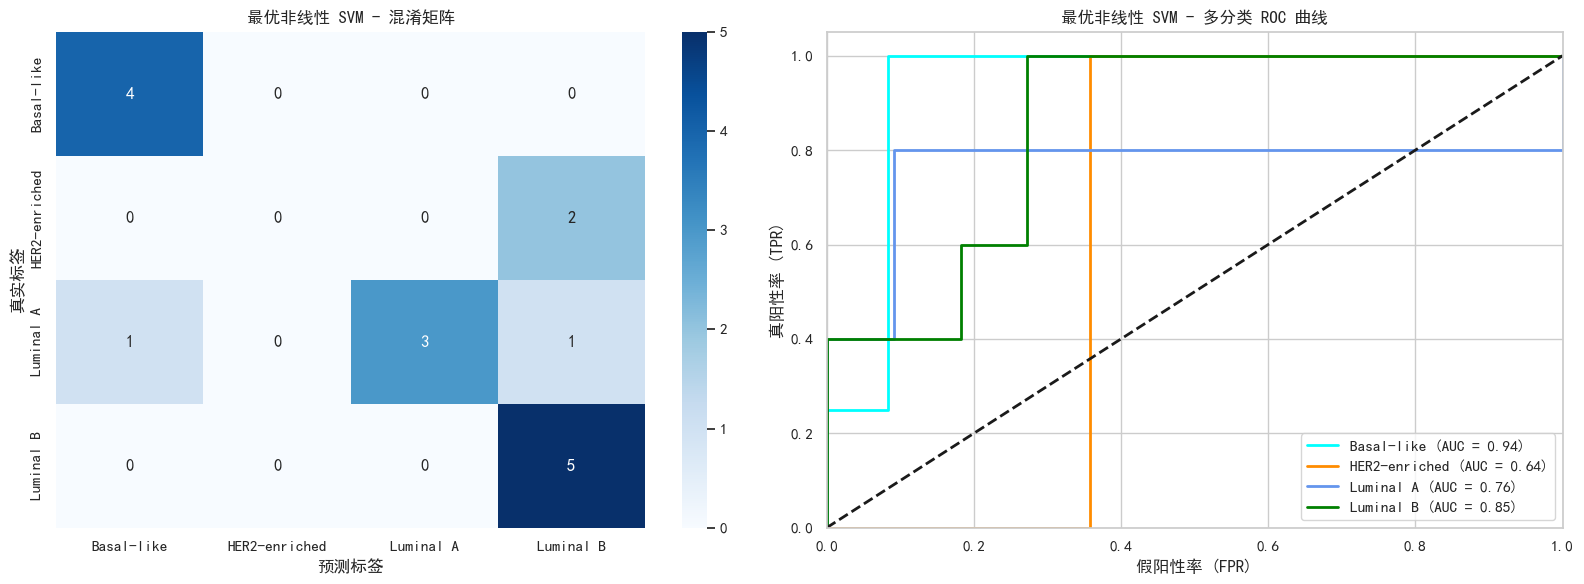

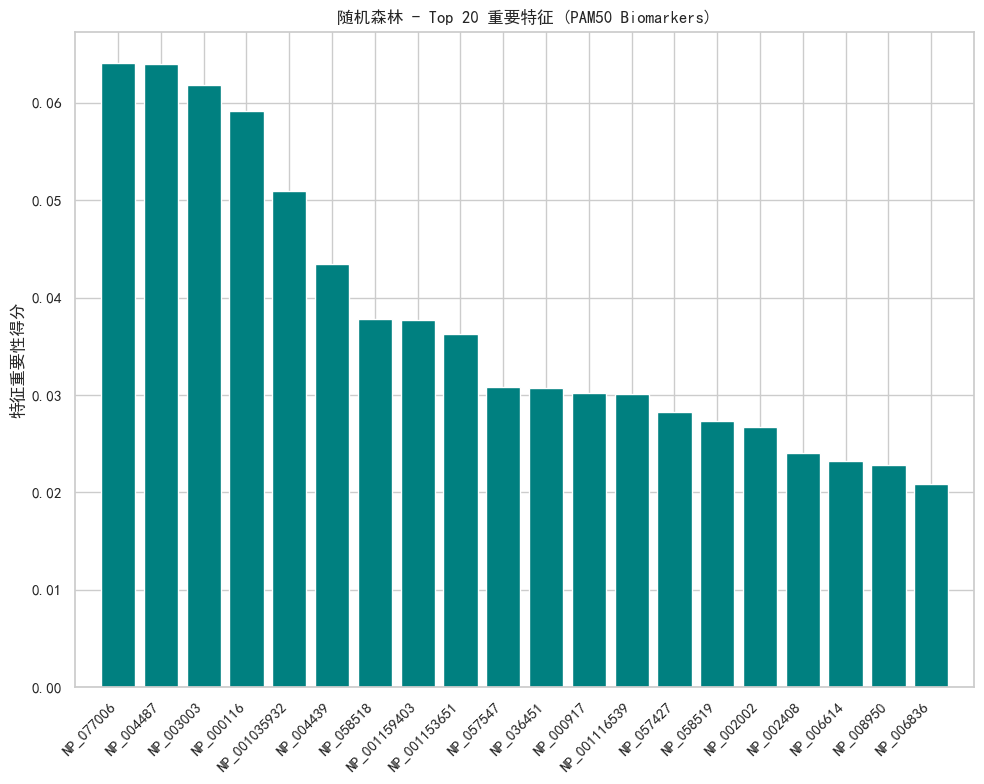

In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
def evaluate_and_visualize(model, model_name, X_test, y_test, target_names):
    print(f"\n{'='*20} 正在评估: {model_name} {'='*20}")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    print(classification_report(y_test, y_pred, target_names=target_names))
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names, ax=axes[0])
    axes[0].set_title(f'{model_name} - 混淆矩阵')
    axes[0].set_ylabel('真实标签')
    axes[0].set_xlabel('预测标签')
    y_test_bin = label_binarize(y_test, classes=range(n_classes))
    colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple']
    for i, color in zip(range(n_classes), colors[:n_classes]):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color=color, lw=2,
                     label=f'{target_names[i]} (AUC = {roc_auc:.2f})')
        
    axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('假阳性率 (FPR)')
    axes[1].set_ylabel('真阳性率 (TPR)')
    axes[1].set_title(f'{model_name} - 多分类 ROC 曲线')
    axes[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --------------------------
# 模型 A: 随机森林 + 交叉验证调参
# --------------------------
print(f"\n{'='*20} 正在执行: 随机森林 交叉验证网格搜索 {'='*20}")
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

# 定义需要交叉验证尝试的参数网格
rf_param_grid = {
    'n_estimators': [100, 200, 300],  # 尝试三种树的数量
    'max_depth': [None, 10, 20],      # 尝试不同的树深度 (防止过拟合)
}

# n_jobs=-1 表示使用所有CPU核心加速计算
rf_grid_search = GridSearchCV(estimator=rf_base, param_grid=rf_param_grid, 
                              cv=cv_strategy, scoring='accuracy', n_jobs=-1)

# 在训练集上进行交叉验证训练
rf_grid_search.fit(X_train_scaled, y_train)

print(f"交叉验证找到的 随机森林 最佳参数: {rf_grid_search.best_params_}")
print(f"交叉验证最高平均准确率: {rf_grid_search.best_score_:.4f}")

# 提取通过交叉验证选出的最佳模型，并在独立的测试集上画图评估
best_rf_model = rf_grid_search.best_estimator_
evaluate_and_visualize(best_rf_model, "最优随机森林", X_test_scaled, y_test, target_names)


# --------------------------
# 模型 B: SVM + 交叉验证调参
# --------------------------
print(f"\n{'='*20} 正在执行: 非线性SVM 交叉验证网格搜索 {'='*20}")
svm_base = SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')

# 定义需要交叉验证尝试的参数网格
svm_param_grid = {
    'C': [0.1, 1, 10],            # 惩罚系数 (正则化强度)
    'gamma': ['scale', 0.01, 0.1] # 核函数的带宽参数
}

svm_grid_search = GridSearchCV(estimator=svm_base, param_grid=svm_param_grid, 
                               cv=cv_strategy, scoring='accuracy', n_jobs=-1)

# 在训练集上进行交叉验证训练
svm_grid_search.fit(X_train_scaled, y_train)

print(f"交叉验证找到的 SVM 最佳参数: {svm_grid_search.best_params_}")
print(f"交叉验证最高平均准确率: {svm_grid_search.best_score_:.4f}")

# 提取最佳模型并在独立测试集上评估
best_svm_model = svm_grid_search.best_estimator_
evaluate_and_visualize(best_svm_model, "最优非线性 SVM", X_test_scaled, y_test, target_names)
#  随机森林专属可视化：特征重要性 (Feature Importance)
importances = best_rf_model.feature_importances_
feature_names = X_df.columns
indices = np.argsort(importances)[::-1]
top_n = 20

plt.figure(figsize=(10, 8))
plt.title("随机森林 - Top 20 重要特征 (PAM50 Biomarkers)")
plt.bar(range(top_n), importances[indices][:top_n], color="teal", align="center")
plt.xticks(range(top_n), [feature_names[i] for i in indices][:top_n], rotation=45, ha='right')
plt.xlim([-1, top_n])
plt.ylabel('特征重要性得分')
plt.tight_layout()
plt.show()

In [20]:
from scipy import stats
annotation_cols = protein.columns[:3]
healthy_cols = protein.columns[-3:]
disease_cols = protein.columns[3:-3]
healthy_data = protein[healthy_cols]
disease_data = protein[disease_cols]
healthy_mean = healthy_data.mean(axis=1)
disease_mean = disease_data.mean(axis=1)
log2fc = disease_mean - healthy_mean 
def calculate_pvalue(row_idx):
    # 提取某一个蛋白在两组中的有效数值 (剔除 NaN)
    h_vals = healthy_data.loc[row_idx].dropna()
    d_vals = disease_data.loc[row_idx].dropna()
    
    # 只有当两组都有至少 2 个有效数据时，才能做 T 检验
    if len(h_vals) >= 2 and len(d_vals) >= 2:
        stat, p = stats.ttest_ind(d_vals, h_vals, equal_var=False)
        return p
    else:
        return np.nan
p_values = [calculate_pvalue(i) for i in protein.index]
diff_results = pd.DataFrame({
    'Protein_ID': protein[protein.columns[0]], # 假设第一列是 RefSeq ID
    'Gene_Symbol': protein['gene_symbol'],
    'Healthy_Mean': healthy_mean,
    'Disease_Mean': disease_mean,
    'Log2FC': log2fc,
    'P_value': p_values
})
diff_results = diff_results.sort_values(by='P_value', ascending=True)
difference = diff_results.loc[diff_results['P_value']<0.05]
print(diff_results.head(10))
print(len(difference))

         Protein_ID Gene_Symbol  Healthy_Mean  Disease_Mean     Log2FC  \
3599      NP_115618      PLXNA1     -6.899769      0.084571   6.984339   
9954      NP_115648        MAF1     -6.554095      0.024387   6.578482   
9949   NP_001121054        ING4     -7.788019     -0.144929   7.643090   
9948      NP_115705        ING5     -7.131676     -0.583974   6.547702   
11650     NP_115732       LSMD1    -10.695969     -0.601453  10.094517   
10865     NP_077275       PPDPF    -11.979863     -0.742196  11.237666   
9988      NP_006318     TIMM23B     -5.445614     -0.008263   5.437350   
10375  NP_001026886      OBFC2A     -7.717523     -0.253512   7.464011   
11726     NP_848642     ZBTB8OS     -6.406826     -0.134965   6.271861   
6296      NP_002410     MAP3K11     -7.531086     -0.322312   7.208774   

            P_value  
3599   5.684956e-67  
9954   9.547018e-60  
9949   1.151274e-59  
9948   2.046394e-53  
11650  4.999343e-53  
10865  5.545300e-53  
9988   7.015872e-53  
10375  6.

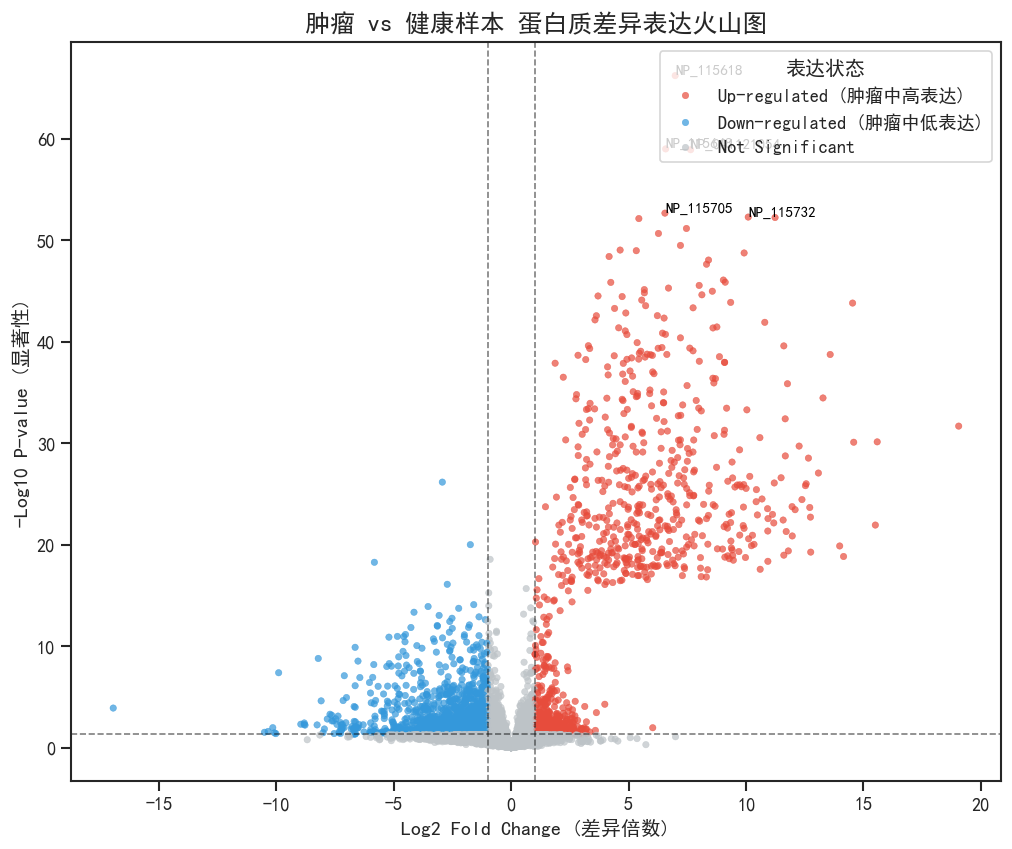

In [21]:
plt.figure(figsize=(10, 8), dpi=120)

# 计算 -log10(P-value) 用于 Y 轴
diff_results['-log10(P)'] = -np.log10(diff_results['P_value'])

# 设定判断显著性的阈值 (通常 P < 0.05 且 |Log2FC| > 1，即相差两倍以上)
p_threshold = -np.log10(0.05)
fc_threshold = 1.0

# 划分蛋白质的三种状态：上调(红)、下调(蓝)、不显著(灰)
conditions = [
    (diff_results['P_value'] < 0.05) & (diff_results['Log2FC'] > fc_threshold),
    (diff_results['P_value'] < 0.05) & (diff_results['Log2FC'] < -fc_threshold)
]
choices = ['Up-regulated (肿瘤中高表达)', 'Down-regulated (肿瘤中低表达)']
diff_results['Status'] = np.select(conditions, choices, default='Not Significant')

# 制定颜色字典
color_dict = {'Up-regulated (肿瘤中高表达)': '#e74c3c', 
              'Down-regulated (肿瘤中低表达)': '#3498db', 
              'Not Significant': '#bdc3c7'}

# 画散点图
sns.scatterplot(data=diff_results, x='Log2FC', y='-log10(P)', 
                hue='Status', palette=color_dict, alpha=0.7, edgecolor=None, s=15)

# 画辅助虚线
plt.axhline(y=p_threshold, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=fc_threshold, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=-fc_threshold, color='black', linestyle='--', linewidth=1, alpha=0.5)

# 为差异最大的前 5 个蛋白打上基因名标签
top_genes = diff_results.head(5)
for i, row in top_genes.iterrows():
    plt.text(row['Log2FC'], row['-log10(P)'] + 0.1, 
             row['Protein_ID'], fontsize=9, color='black', fontweight='bold')

plt.title("肿瘤 vs 健康样本 蛋白质差异表达火山图", fontsize=15)
plt.xlabel("Log2 Fold Change (差异倍数)", fontsize=12)
plt.ylabel("-Log10 P-value (显著性)", fontsize=12)
plt.legend(title='表达状态', loc='upper right')
plt.show()

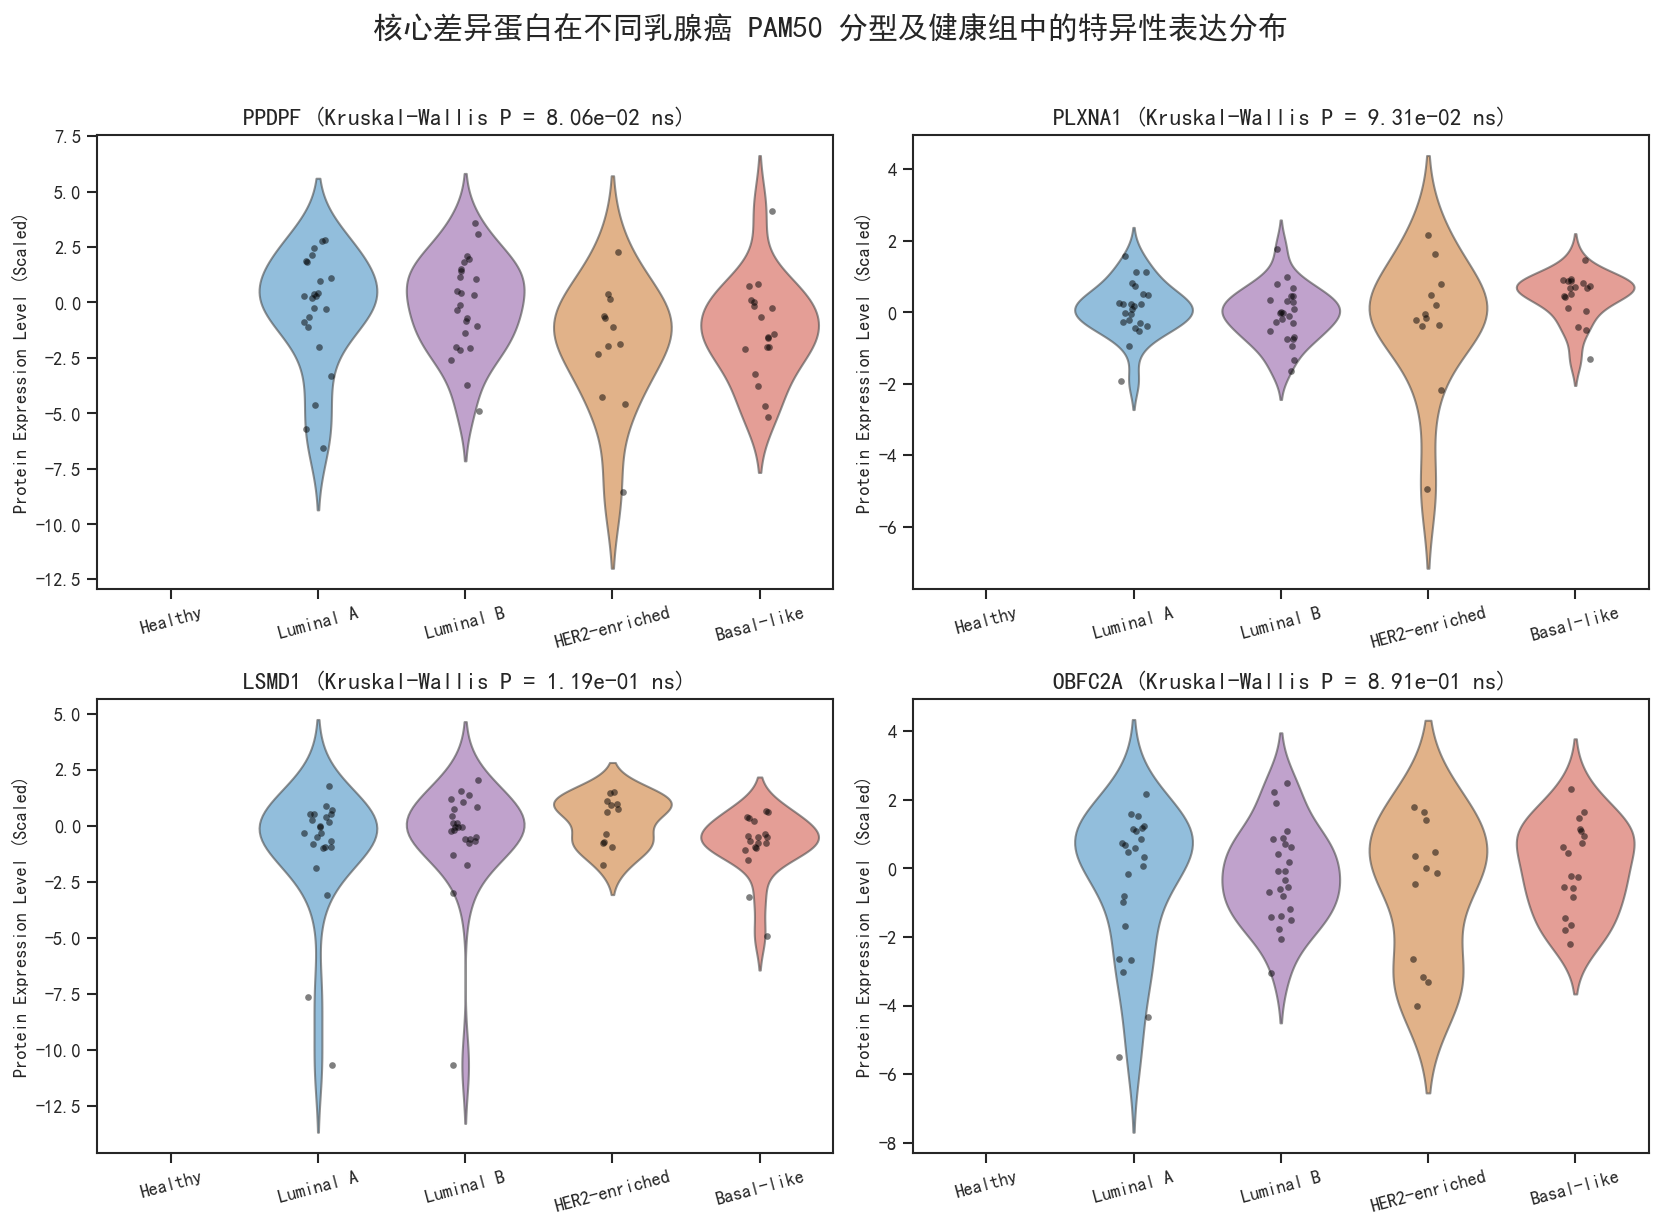

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置图表风格
sns.set_theme(style="ticks", palette="muted")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 支持中文标题
plt.rcParams['axes.unicode_minus'] = False

# ================= 1. 准备绘图数据 =================
# 假设我们要重点探究这 4 个在火山图上最突出的明星蛋白
# ⚠️ 注意：请将这里的 NP_xxxx 替换为你真实数据中这 4 个蛋白对应的 RefSeq ID！
target_genes = {
    'NP_077275': 'PPDPF',    # 假定对应 ID，请替换
    'NP_115618': 'PLXNA1',   # 假定对应 ID，请替换
    'NP_115732': 'LSMD1',    # 假定对应 ID，请替换
    'NP_001026886': 'OBFC2A' # 假定对应 ID，请替换
}

# 构建一个包含样本ID、PAM50 亚型和对应蛋白表达量的数据框
plot_data = pd.DataFrame()

# 1.1 先提取肿瘤样本的数据 (带有 PAM50 标签)
tumor_data = merged[['SampleID', 'PAM50 mRNA']].copy()
tumor_data.rename(columns={'PAM50 mRNA': 'Subtype'}, inplace=True)
tumor_data['Subtype'] = tumor_data['Subtype'].fillna('Unknown')
# 过滤掉标签未知的样本
tumor_data = tumor_data[tumor_data['Subtype'] != 'Unknown']

# 把蛋白质的表达量拼接到 tumor_data 中
for protein_id, gene_name in target_genes.items():
    if protein_id in merged_numerical.columns:
        tumor_data[gene_name] = merged_numerical[protein_id].values
    else:
        print(f"警告：未找到 {gene_name} 的蛋白 ID ({protein_id})，请检查！")

# 1.2 加入健康对照组样本 (假设前文提到的健康样本列名为 healthy_cols)
# 为了画图对比，我们把健康样本也加进来，给它们一个专属标签 "Healthy"
healthy_data = protein[healthy_cols].apply(pd.to_numeric, errors='coerce').T
healthy_data = healthy_data.reset_index().rename(columns={'index': 'SampleID'})
healthy_data['Subtype'] = 'Healthy'

# 提取目标蛋白的表达量
for protein_id, gene_name in target_genes.items():
    if protein_id in healthy_data.columns:
        healthy_data[gene_name] = healthy_data[protein_id].values

# 合并肿瘤与健康组数据
final_plot_data = pd.concat([tumor_data, healthy_data], ignore_index=True)


# ================= 2. 绘制多面板小提琴图 =================
# 我们要画 4 个图，拼成一个 2x2 的大图
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)
axes = axes.flatten()

# 指定在 X 轴上的展示顺序 (让 Healthy 放在最前面作为基准)
subtype_order = ['Healthy', 'Luminal A', 'Luminal B', 'HER2-enriched', 'Basal-like']
# 定义亚型的专属颜色
custom_palette = {'Healthy': '#2ecc71', 'Luminal A': '#3498db', 'Luminal B': '#9b59b6', 
                  'HER2-enriched': '#e67e22', 'Basal-like': '#e74c3c'}

for i, (protein_id, gene_name) in enumerate(target_genes.items()):
    ax = axes[i]
    
    # 画小提琴图 (展示数据密度分布)
    sns.violinplot(x='Subtype', y=gene_name, data=final_plot_data, 
                   order=subtype_order, palette=custom_palette, ax=ax, inner=None, alpha=0.6)
    
    # 叠加带有抖动效果的散点图 (展示每一个真实的病人数据点)
    sns.stripplot(x='Subtype', y=gene_name, data=final_plot_data, 
                  order=subtype_order, color="black", alpha=0.5, size=4, jitter=True, ax=ax)
    
    # 统计检验：Kruskal-Wallis 检验 (比较四种肿瘤亚型之间是否存在显著差异)
    # 提取四种肿瘤亚型的表达量数据
    subtypes_data = [final_plot_data[final_plot_data['Subtype'] == st][gene_name].dropna() 
                     for st in ['Luminal A', 'Luminal B', 'HER2-enriched', 'Basal-like']]
    
    # 如果数据有效则进行检验
    if all(len(d) > 0 for d in subtypes_data):
        stat, p_val = stats.kruskal(*subtypes_data)
        
        # 将 P 值标在子图的标题上
        sig_stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        ax.set_title(f"{gene_name} (Kruskal-Wallis P = {p_val:.2e} {sig_stars})", fontsize=14, fontweight='bold')
    else:
        ax.set_title(f"{gene_name}", fontsize=14, fontweight='bold')

    ax.set_xlabel('')
    ax.set_ylabel('Protein Expression Level (Scaled)', fontsize=11)
    
    # 旋转 X 轴标签，防止重叠
    ax.tick_params(axis='x', rotation=15)

# 整体排版调整
plt.suptitle("核心差异蛋白在不同乳腺癌 PAM50 分型及健康组中的特异性表达分布", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()